# FracAtlas Data Exploration

## Import libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read data

In [15]:
import pandas as pd
import os

# =====================================================================
# Configuration
# =====================================================================
BASE_DIR = os.getcwd()

FRACATLAS_DIR = os.path.join(BASE_DIR, "..", "data", "FracAtlas")
REPORT_DIR = os.path.join(FRACATLAS_DIR, "reports")
DATASET_CSV = os.path.join(FRACATLAS_DIR, "dataset.csv")

# =====================================================================
# Đọc file dữ liệu
# =====================================================================
# Kiểm tra nhanh xem file có tồn tại không trước khi đọc
if not os.path.exists(DATASET_CSV):
    print(f"Lỗi: Không tìm thấy file tại đường dẫn:\n{os.path.abspath(DATASET_CSV)}")
else:
    df = pd.read_csv(DATASET_CSV)

    print("="*50)
    print("1. THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU FRACATLAS")
    print("="*50)
    print(f"Tổng số ảnh (hàng): {df.shape[0]}")
    print(f"Số lượng thuộc tính (cột): {df.shape[1]}")

    print("\nThông tin các cột và kiểu dữ liệu:")
    print(df.info())

    print("\nKiểm tra dữ liệu khuyết thiếu (Missing values):")
    missing = df.isnull().sum()
    if missing.any():
        print(missing[missing > 0])
    else:
        print("Tuyệt vời, không có dữ liệu bị thiếu!")

    # Hiển thị 5 dòng đầu tiên
    display(df.head())

1. THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU FRACATLAS
Tổng số ảnh (hàng): 4083
Số lượng thuộc tính (cột): 13

Thông tin các cột và kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 4083 entries, 0 to 4082
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   image_id        4083 non-null   str  
 1   hand            4083 non-null   int64
 2   leg             4083 non-null   int64
 3   hip             4083 non-null   int64
 4   shoulder        4083 non-null   int64
 5   mixed           4083 non-null   int64
 6   hardware        4083 non-null   int64
 7   multiscan       4083 non-null   int64
 8   fractured       4083 non-null   int64
 9   fracture_count  4083 non-null   int64
 10  frontal         4083 non-null   int64
 11  lateral         4083 non-null   int64
 12  oblique         4083 non-null   int64
dtypes: int64(12), str(1)
memory usage: 470.6 KB
None

Kiểm tra dữ liệu khuyết thiếu (Missing values):
Tuyệt vời, không có d

,image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
0,IMG0000000.jpg,0,1,0,0,0,0,1,0,0,1,1,0
1,IMG0000001.jpg,0,1,0,0,0,0,1,0,0,1,1,0
2,IMG0000002.jpg,0,1,0,0,0,0,1,0,0,1,1,0
3,IMG0000003.jpg,0,1,0,0,0,0,1,0,0,0,1,1
4,IMG0000004.jpg,0,1,0,0,0,0,1,0,0,0,1,1


## Fractured sample


2. THỐNG KÊ LỚP GÃY XƯƠNG (FRACTURED)
fractured
Bình thường (0)    3366
Gãy xương (1)       717
Name: count, dtype: int64


C:\Users\lebat\AppData\Local\Temp\ipykernel_18476\410025491.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='fractured', palette=['#2ecc71', '#e74c3c'])


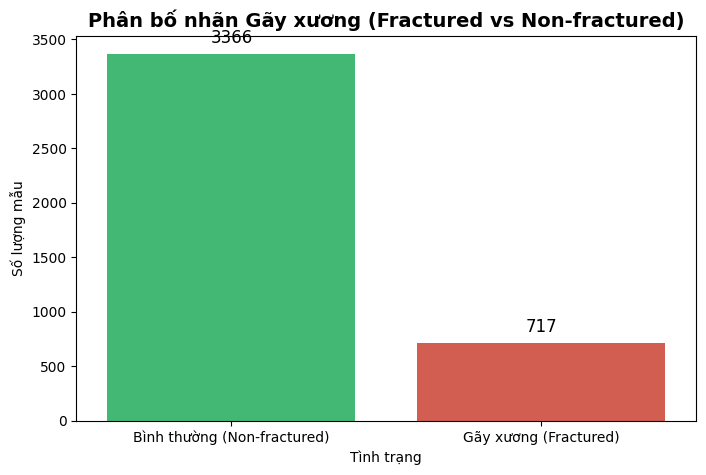


Thống kê số lượng vết gãy trên các ca dương tính (fractured == 1):
fracture_count
1    546
2    146
3     17
4      7
5      1
Name: count, dtype: int64


In [16]:
print("\n" + "="*50)
print("2. THỐNG KÊ LỚP GÃY XƯƠNG (FRACTURED)")
print("="*50)

# Đếm số lượng nhãn
fracture_counts = df['fractured'].value_counts().rename(index={0: 'Bình thường (0)', 1: 'Gãy xương (1)'})
print(fracture_counts)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='fractured', palette=['#2ecc71', '#e74c3c'])
plt.title('Phân bố nhãn Gãy xương (Fractured vs Non-fractured)', fontsize=14, fontweight='bold')
plt.xlabel('Tình trạng')
plt.ylabel('Số lượng mẫu')
plt.xticks(ticks=[0, 1], labels=['Bình thường (Non-fractured)', 'Gãy xương (Fractured)'])

# Hiển thị số lượng cụ thể trên từng cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# Thống kê số lượng vết gãy (fracture_count) trên các ca có gãy
print("\nThống kê số lượng vết gãy trên các ca dương tính (fractured == 1):")
print(df[df['fractured'] == 1]['fracture_count'].value_counts().sort_index())

## Anatomical locations


3. PHÂN BỐ VỊ TRÍ GIẢI PHẪU (ANATOMY)
leg         2273
hand        1538
mixed        398
shoulder     349
hip          338
dtype: int64


C:\Users\lebat\AppData\Local\Temp\ipykernel_18476\1145203255.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anatomy_counts.index, y=anatomy_counts.values, palette='Blues_r')


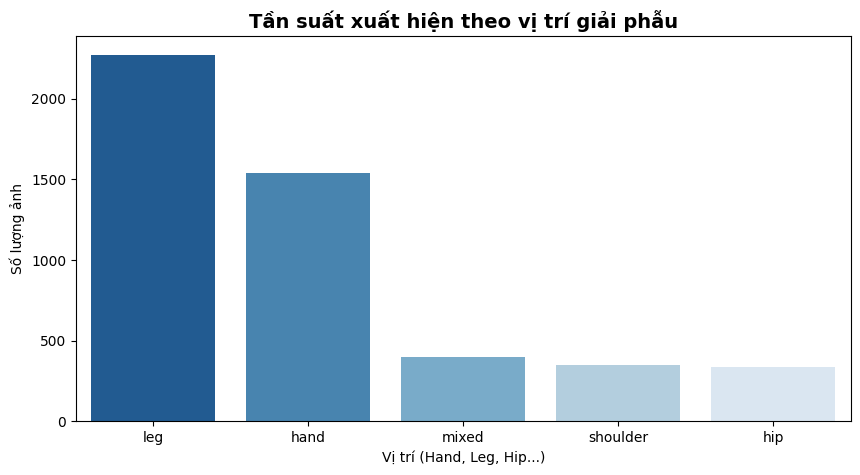

In [17]:
print("\n" + "="*50)
print("3. PHÂN BỐ VỊ TRÍ GIẢI PHẪU (ANATOMY)")
print("="*50)

# Các cột chứa thông tin vị trí giải phẫu
anatomy_cols = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

# Tính tổng số mẫu cho từng vị trí
anatomy_counts = df[anatomy_cols].sum().sort_values(ascending=False)
print(anatomy_counts)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.barplot(x=anatomy_counts.index, y=anatomy_counts.values, palette='Blues_r')
plt.title('Tần suất xuất hiện theo vị trí giải phẫu', fontsize=14, fontweight='bold')
plt.xlabel('Vị trí (Hand, Leg, Hip...)')
plt.ylabel('Số lượng ảnh')
plt.show()

## Others


4. GÓC CHỤP & THUỘC TÍNH PHỤ


C:\Users\lebat\AppData\Local\Temp\ipykernel_18476\110666974.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=view_counts.index, y=view_counts.values, ax=axes[0], palette='magma')
C:\Users\lebat\AppData\Local\Temp\ipykernel_18476\110666974.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=other_counts.index, y=other_counts.values, ax=axes[1], palette='viridis')


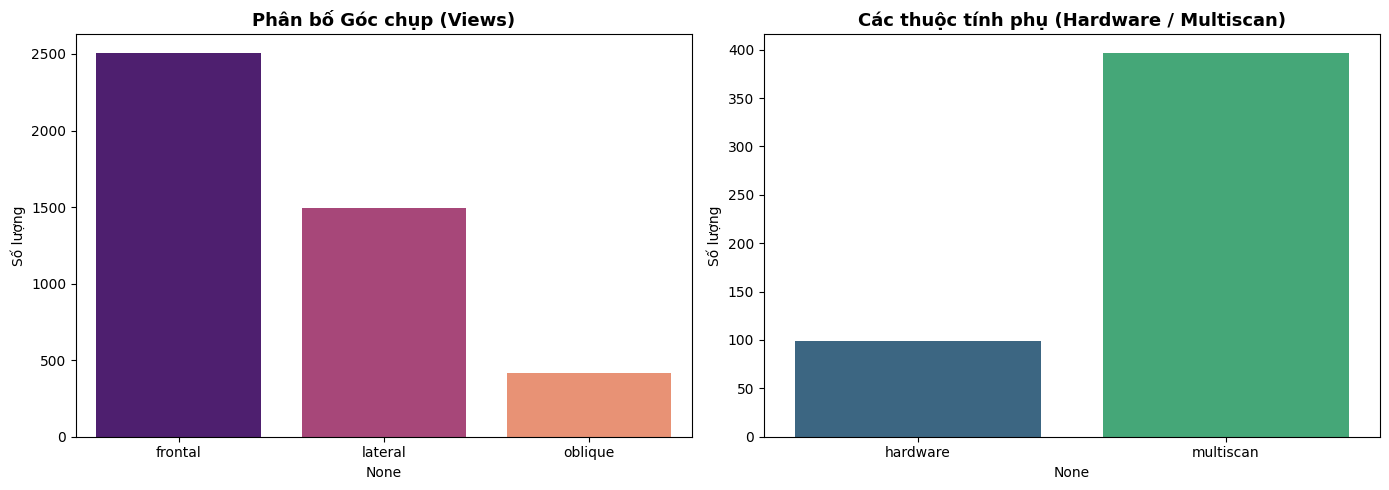

In [18]:
print("\n" + "="*50)
print("4. GÓC CHỤP & THUỘC TÍNH PHỤ")
print("="*50)

# Các cột góc chụp và thuộc tính phụ (phần cứng nẹp vít, quét nhiều lần)
view_cols = ['frontal', 'lateral', 'oblique']
other_cols = ['hardware', 'multiscan']

# Tính tổng
view_counts = df[view_cols].sum()
other_counts = df[other_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ góc chụp
sns.barplot(x=view_counts.index, y=view_counts.values, ax=axes[0], palette='magma')
axes[0].set_title('Phân bố Góc chụp (Views)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng')

# Biểu đồ thuộc tính phụ
sns.barplot(x=other_counts.index, y=other_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Các thuộc tính phụ (Hardware / Multiscan)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

## Heatmap


5. TƯƠNG QUAN GIỮA VỊ TRÍ XƯƠNG VÀ TÌNH TRẠNG GÃY


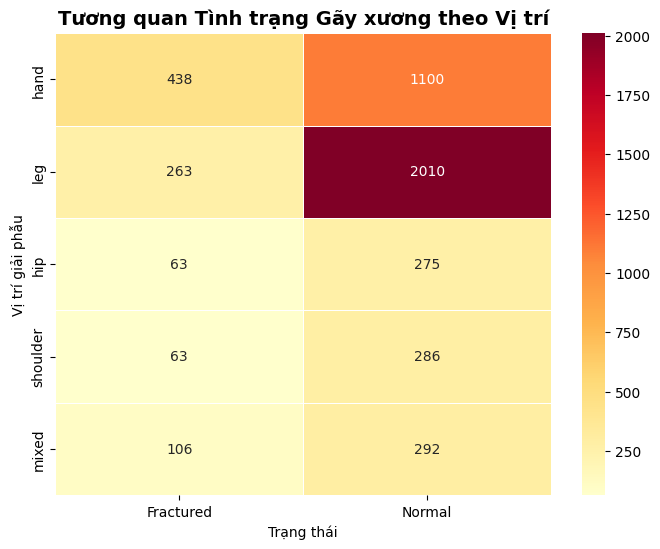


Tỷ lệ gãy xương trên từng vị trí:


,Fracture_Rate (%)
hand,28.48
mixed,26.63
hip,18.64
shoulder,18.05
leg,11.57


In [19]:
print("\n" + "="*50)
print("5. TƯƠNG QUAN GIỮA VỊ TRÍ XƯƠNG VÀ TÌNH TRẠNG GÃY")
print("="*50)

# Tạo ma trận chéo để xem số lượng gãy xương theo từng vị trí
cross_tab = pd.DataFrame()

for anatomy in anatomy_cols:
    # Đếm số ca có vị trí anatomy này VÀ bị gãy (fractured == 1)
    fractured_count = len(df[(df[anatomy] == 1) & (df['fractured'] == 1)])
    # Đếm số ca có vị trí anatomy này VÀ không gãy (fractured == 0)
    normal_count = len(df[(df[anatomy] == 1) & (df['fractured'] == 0)])
    
    cross_tab.loc[anatomy, 'Fractured'] = fractured_count
    cross_tab.loc[anatomy, 'Normal'] = normal_count

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt="g", cmap='YlOrRd', linewidths=.5)
plt.title('Tương quan Tình trạng Gãy xương theo Vị trí', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái')
plt.ylabel('Vị trí giải phẫu')
plt.show()

# Tính tỷ lệ gãy trên từng vị trí
cross_tab['Fracture_Rate (%)'] = round((cross_tab['Fractured'] / (cross_tab['Fractured'] + cross_tab['Normal'])) * 100, 2)
print("\nTỷ lệ gãy xương trên từng vị trí:")
display(cross_tab[['Fracture_Rate (%)']].sort_values(by='Fracture_Rate (%)', ascending=False))

In [20]:
# Giả sử đường dẫn tới 2 file của bạn (bạn hãy điều chỉnh lại tên file cho khớp với thực tế nhé)
split_path = r'C:\Users\lebat\Documents\Github\xbone-net\data\FracAtlas\fracatlas-split.csv'
labels_path = r'C:\Users\lebat\Documents\Github\xbone-net\data\FracAtlas\fracatlas-labels.csv'

# 1. Đọc 2 file dữ liệu
print("\n" + "="*50)
print("6. NẠP VÀ MAP DỮ LIỆU SPLIT & LABELS")
print("="*50)

df_split = pd.read_csv(split_path)
df_labels = pd.read_csv(labels_path)

print(f"Số lượng mẫu trong file split: {df_split.shape[0]}")
print(f"Số lượng mẫu trong file labels: {df_labels.shape[0]}")

# 2. Map (Gộp) hai dataframe lại với nhau thông qua cột 'image_id'
# Dùng how='inner' để chỉ giữ lại những ảnh có mặt ở cả 2 file
df_merged = pd.merge(df_split, df_labels, on='image_id', how='inner')

print(f"\nSau khi gộp, bộ dữ liệu có kích thước: {df_merged.shape}")
display(df_merged.head())

# 3. Thống kê số lượng nhãn 0 và 1 trên các tập Train / Val / Test
print("\n" + "="*50)
print("7. THỐNG KÊ PHÂN BỐ NHÃN 0 VÀ 1 TRÊN CÁC TẬP")
print("="*50)

# Lấy danh sách các cột là nhãn (loại bỏ 'image_id' và 'split')
label_cols = [col for col in df_merged.columns if col not in ['image_id', 'split']]

# Duyệt qua từng nhãn và in ra thống kê
for label in label_cols:
    print(f"\n---> Thống kê cho nhãn: [{label.upper()}]")
    
    # Hàm crosstab giúp tạo bảng chéo thống kê số lượng 0 và 1 theo từng tập split
    stat_table = pd.crosstab(
        index=df_merged['split'], 
        columns=df_merged[label], 
        margins=True, # Thêm cột/hàng tính tổng (All)
        margins_name="Tổng"
    )
    
    # Đổi tên cột cho dễ nhìn (0: Bình thường/Không có, 1: Có)
    stat_table.rename(columns={0.0: 'Class 0', 1.0: 'Class 1', 0: 'Class 0', 1: 'Class 1'}, inplace=True)
    
    display(stat_table)
    
    # (Tùy chọn) In thêm tỷ lệ % Class 1 trong từng tập để xem dữ liệu có bị mất cân bằng không
    print("Tỷ lệ mẫu Dương tính (Class 1) trên từng tập:")
    for split_name in df_merged['split'].unique():
        total = len(df_merged[df_merged['split'] == split_name])
        positives = df_merged[(df_merged['split'] == split_name) & (df_merged[label] == 1)].shape[0]
        ratio = (positives / total) * 100 if total > 0 else 0
        print(f"  - Tập {split_name:8s}: {positives}/{total} mẫu ({ratio:.2f}%)")


6. NẠP VÀ MAP DỮ LIỆU SPLIT & LABELS
Số lượng mẫu trong file split: 4083
Số lượng mẫu trong file labels: 4083

Sau khi gộp, bộ dữ liệu có kích thước: (4083, 3)


,image_id,split,fractured
0,IMG0000052.jpg,train,0
1,IMG0002910.jpg,train,0
2,IMG0003776.jpg,train,0
3,IMG0001422.jpg,train,0
4,IMG0000510.jpg,train,0



7. THỐNG KÊ PHÂN BỐ NHÃN 0 VÀ 1 TRÊN CÁC TẬP

---> Thống kê cho nhãn: [FRACTURED]


fractured,Class 0,Class 1,Tổng
split,,,
test,337,72,409
train,2692,573,3265
validate,337,72,409
Tổng,3366,717,4083


Tỷ lệ mẫu Dương tính (Class 1) trên từng tập:
  - Tập train   : 573/3265 mẫu (17.55%)
  - Tập validate: 72/409 mẫu (17.60%)
  - Tập test    : 72/409 mẫu (17.60%)


📊 FracAtlas Report Uniqueness Analysis

────────────────────────────────────────
  Total reports:       4083
  Unique reports:      4038 (98.9%)
  Duplicate reports:   45
  Largest dup group:   2
────────────────────────────────────────

📋 Uniqueness by Fracture Status:
────────────────────────────────────────
  Non-fractured  : 3321/3366 unique (98.7%)
  Fractured      :  717/ 717 unique (100.0%)

📋 Uniqueness by Body Part:
────────────────────────────────────────
  hand        : 1527/1538 unique (99.3%)
  leg         : 2240/2273 unique (98.5%)
  hip         :  337/ 338 unique (99.7%)
  shoulder    :  349/ 349 unique (100.0%)
  mixed       :  398/ 398 unique (100.0%)

📋 Top 10 Most Duplicated Reports:
────────────────────────────────────────────────────────────
  [2x] a frontal radiograph of the lower extremity demonstrating normal bony alignment....
  [2x] an plain film of oblique view of the lower limb with no signs of fracture. in a ...
  [2x] a radiograph of frontal radiograph of 

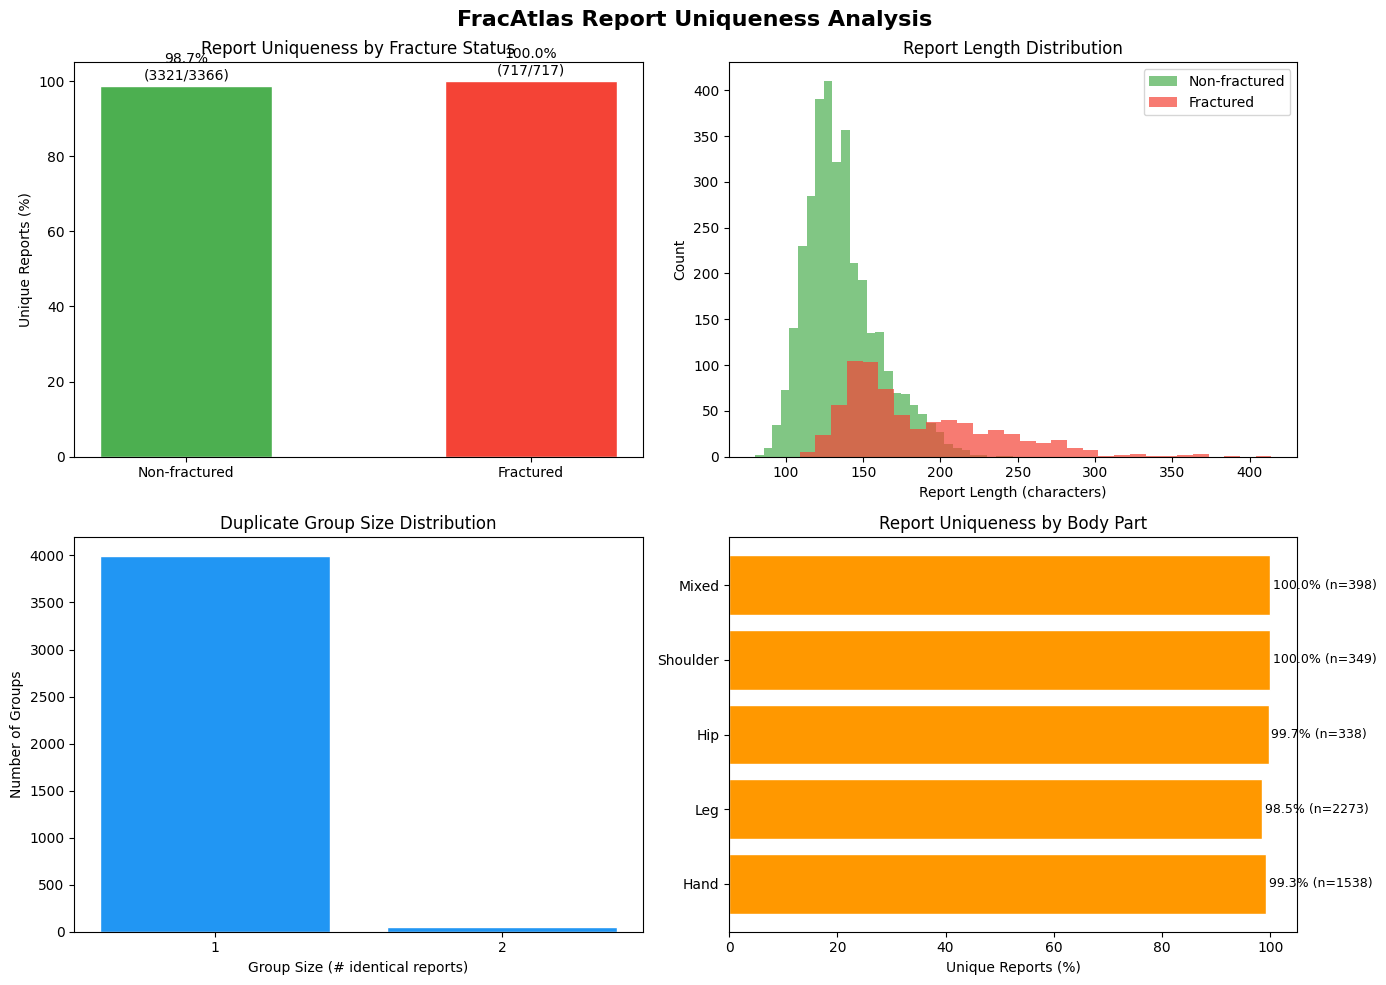


📝 Sample Reports (Fractured vs Non-Fractured)

--- Fractured Samples ---
  [IMG0001870.jpg] An plain film of anteroposterior projection of the tibial shaft area exhibiting a fine fracture involving the central region. In a standard-resolution acquisition.
  [IMG0002475.jpg] Radiographic lateral projection of the tibial shaft area revealing 2 fracture sites: a clearly visible fracture in the mid-central zone and a non-displaced fracture in the distal midline area. In a standard clinical view.
  [IMG0000600.jpg] Radiographic lateral plane radiograph of the manus showing a hairline fracture in the mid-central zone. In a standard clinical view.
  [IMG0003734.jpg] Radiographic cross-table lateral view of the metacarpals and phalanges revealing a fine fracture line in the central region. In a compact single-view format.
  [IMG0002934.jpg] An image of a frontal radiograph of the metacarpals and phalanges demonstrating a subtle cortical break in the mid-central zone. In a standard-resolution 

In [21]:
"""
FracAtlas Report Uniqueness Explorer
====================================
Run this script to analyze the uniqueness and diversity of generated reports.
Copy cells into FracAtlas.ipynb or run standalone.

Usage:
    python notebooks/explore_reports.py
"""

import sys

import os
import collections

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. Load all reports and metadata
# =====================================================================
print("=" * 60)
print("📊 FracAtlas Report Uniqueness Analysis")
print("=" * 60)

df = pd.read_csv(DATASET_CSV)

# Read all reports
reports = {}
for _, row in df.iterrows():
    fname = str(row["image_id"])
    base = os.path.splitext(fname)[0]
    report_path = os.path.join(REPORT_DIR, f"{base}.txt")
    if os.path.exists(report_path):
        with open(report_path, "r", encoding="utf-8") as f:
            reports[fname] = f.read().strip()
    else:
        reports[fname] = ""

df["report"] = df["image_id"].map(reports)
df["report_lower"] = df["report"].str.lower()
df["report_len"] = df["report"].str.len()
df["report_words"] = df["report"].str.split().str.len()

# =====================================================================
# 2. Overall Uniqueness Stats
# =====================================================================
total = len(df)
unique = df["report_lower"].nunique()
dup_count = total - unique
max_dup = df["report_lower"].value_counts().iloc[0]

print(f"\n{'─' * 40}")
print(f"  Total reports:       {total}")
print(f"  Unique reports:      {unique} ({unique/total*100:.1f}%)")
print(f"  Duplicate reports:   {dup_count}")
print(f"  Largest dup group:   {max_dup}")
print(f"{'─' * 40}\n")

# =====================================================================
# 3. Uniqueness by Class (Fractured vs Non-Fractured)
# =====================================================================
print("📋 Uniqueness by Fracture Status:")
print("─" * 40)
for label, group in df.groupby("fractured"):
    n = len(group)
    u = group["report_lower"].nunique()
    status = "Fractured" if label == 1 else "Non-fractured"
    print(f"  {status:15s}: {u:4d}/{n:4d} unique ({u/n*100:.1f}%)")
print()

# =====================================================================
# 4. Uniqueness by Body Part
# =====================================================================
body_cols = ["hand", "leg", "hip", "shoulder", "mixed"]
print("📋 Uniqueness by Body Part:")
print("─" * 40)
for col in body_cols:
    group = df[df[col] == 1]
    n = len(group)
    u = group["report_lower"].nunique()
    print(f"  {col:12s}: {u:4d}/{n:4d} unique ({u/n*100:.1f}%)")
print()

# =====================================================================
# 5. Top Duplicated Reports
# =====================================================================
print("📋 Top 10 Most Duplicated Reports:")
print("─" * 60)
dup_counts = df["report_lower"].value_counts()
for i, (text, cnt) in enumerate(dup_counts.head(10).items()):
    if cnt <= 1:
        break
    print(f"  [{cnt}x] {text[:80]}...")
print()

# =====================================================================
# 6. Report Length Distribution
# =====================================================================
print("📋 Report Length Statistics:")
print("─" * 40)
print(f"  Mean characters: {df['report_len'].mean():.1f}")
print(f"  Std characters:  {df['report_len'].std():.1f}")
print(f"  Min characters:  {df['report_len'].min()}")
print(f"  Max characters:  {df['report_len'].max()}")
print(f"  Mean words:      {df['report_words'].mean():.1f}")
print()

# =====================================================================
# 7. Visualizations
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FracAtlas Report Uniqueness Analysis", fontsize=16, fontweight="bold")

# 7a. Uniqueness by class (bar chart)
ax = axes[0, 0]
class_stats = []
for label in [0, 1]:
    group = df[df["fractured"] == label]
    n = len(group)
    u = group["report_lower"].nunique()
    class_stats.append({
        "Class": "Non-fractured" if label == 0 else "Fractured",
        "Total": n, "Unique": u, "Duplicates": n - u,
        "Unique %": u / n * 100
    })
cs = pd.DataFrame(class_stats)
bars = ax.bar(cs["Class"], cs["Unique %"], color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
ax.set_ylabel("Unique Reports (%)")
ax.set_title("Report Uniqueness by Fracture Status")
ax.set_ylim(0, 105)
for bar, (_, cs_row) in zip(bars, cs.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{cs_row['Unique %']:.1f}%\n({cs_row['Unique']}/{cs_row['Total']})",
            ha="center", va="bottom", fontsize=10)

# 7b. Report length distribution
ax = axes[0, 1]
ax.hist(df[df["fractured"] == 0]["report_len"], bins=30, alpha=0.7, label="Non-fractured", color="#4CAF50")
ax.hist(df[df["fractured"] == 1]["report_len"], bins=30, alpha=0.7, label="Fractured", color="#F44336")
ax.set_xlabel("Report Length (characters)")
ax.set_ylabel("Count")
ax.set_title("Report Length Distribution")
ax.legend()

# 7c. Duplicate group size distribution
ax = axes[1, 0]
dup_sizes = dup_counts.value_counts().sort_index()
ax.bar(dup_sizes.index, dup_sizes.values, color="#2196F3", edgecolor="white")
ax.set_xlabel("Group Size (# identical reports)")
ax.set_ylabel("Number of Groups")
ax.set_title("Duplicate Group Size Distribution")
ax.set_xticks(dup_sizes.index)

# 7d. Uniqueness by body part
ax = axes[1, 1]
bp_data = []
for col in body_cols:
    group = df[df[col] == 1]
    n = len(group)
    u = group["report_lower"].nunique()
    bp_data.append({"Body Part": col.capitalize(), "Unique %": u / n * 100, "Count": n})
bp_df = pd.DataFrame(bp_data)
bars = ax.barh(bp_df["Body Part"], bp_df["Unique %"], color="#FF9800", edgecolor="white")
ax.set_xlabel("Unique Reports (%)")
ax.set_title("Report Uniqueness by Body Part")
ax.set_xlim(0, 105)
for bar, (_, bp_row) in zip(bars, bp_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{bp_row['Unique %']:.1f}% (n={bp_row['Count']})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# =====================================================================
# 8. Sample Reports Comparison (Before/After style)
# =====================================================================
print("\n" + "=" * 60)
print("📝 Sample Reports (Fractured vs Non-Fractured)")
print("=" * 60)

print("\n--- Fractured Samples ---")
frac_samples = df[df["fractured"] == 1].sample(5, random_state=42)
for _, row in frac_samples.iterrows():
    print(f"  [{row['image_id']}] {row['report']}")

print("\n--- Non-Fractured Samples ---")
nonfrac_samples = df[df["fractured"] == 0].sample(5, random_state=42)
for _, row in nonfrac_samples.iterrows():
    print(f"  [{row['image_id']}] {row['report']}")

print("\n✅ Analysis complete!")
